Markdown
## 1. Importation et Chargement des données


J'intègre le chargement des données dans une fonction `load_ecg_data()`. Cela permet de clarifier la logique (Clean Code), d'éviter les répétitions, et de rendre le code plus facile à lire et à maintenir.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# URL consultée pour comprendre comment charger un fichier texte :
# https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html

def load_ecg_data(file_path):
    """Charge les données brutes de l'ECG depuis un fichier texte."""
    data = np.loadtxt(file_path)
    return data

# On utilise la fonction que l'on vient de créer pour lire notre fichier
file_path = "data/ECGu.txt"
raw_ecg_data = load_ecg_data(file_path)

print(f"Dimensions du tableau : {raw_ecg_data.shape}")

Dimensions du tableau : (6500, 3)


## 2. Affichage des données brutes

Je créée une fonction plot_raw_ecg() pour isoler la logique d'affichage. Cela permet de générer le graphique rapidement et de vérifier visuellement que nos données ressemblent bien à un signal cardiaque avant de faire des calculs mathématiques dessus.

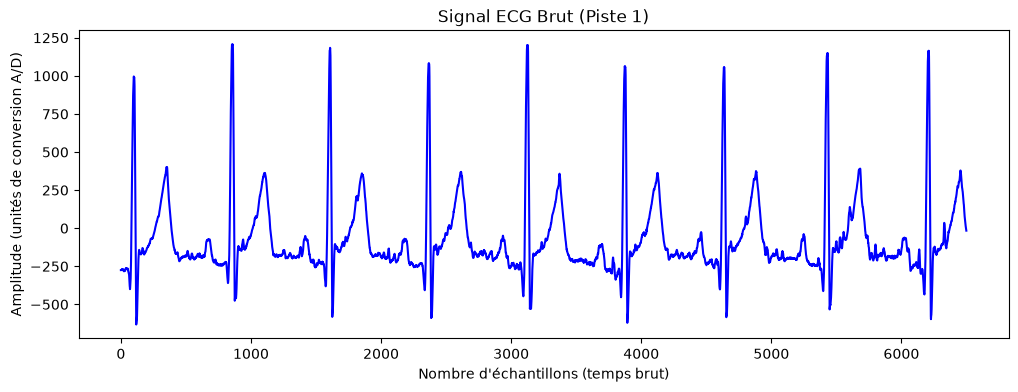

In [35]:
# URL consultée pour comprendre la création de graphiques simples :
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

def plot_raw_ecg(data):
    """Affiche la première piste (colonne 0) de l'ECG brut pour vérification visuelle."""
    plt.figure(figsize=(12, 4))
    plt.plot(data[:, 0], color='blue') 
    plt.title("Signal ECG Brut (Piste 1)")
    plt.xlabel("Nombre d'échantillons (temps brut)")
    plt.ylabel("Amplitude (unités de conversion A/D)")
    plt.show()

# On exécute la fonction pour dessiner le graphique
plot_raw_ecg(raw_ecg_data)

## 3. Conversion en unités standards (mV et secondes)
    
La machine enregistre 1000 mesures par seconde (1000 Hz) avec un gain de 1024 mV par unité. Je créée une fonction rescale_ecg_data() pour appliquer ces formules mathématiques. Cette séparation permet de garder nos données brutes intactes tout en générant un nouveau jeu de données prêt pour l'analyse médicale.

In [36]:
# URL consultée pour générer une suite de nombres (axe du temps) :
# https://numpy.org/doc/stable/reference/generated/numpy.arange.html

def rescale_ecg_data(data):
    """
    Convertit les données brutes en secondes (axe X) et en millivolts (axe Y).
    """
    # 1. Axe du temps : on a 1000 mesures par seconde, on divise donc par 1000
    nb_mesures = len(data)
    time_sec = np.arange(nb_mesures) / 1000.0
    
    # 2. Axe de l'amplitude : 1 unité machine = 1024 µV = 1.024 mV
    ecg_mV = data * 1.024
    
    return time_sec, ecg_mV

# On exécute la conversion
time, rescaled_ecg_data = rescale_ecg_data(raw_ecg_data)

# Vérification rapide
print(f"Durée totale de l'enregistrement : {time[-1]} secondes")
print(f"Valeur maximale en mV : {np.max(rescaled_ecg_data):.2f} mV")

Durée totale de l'enregistrement : 6.499 secondes
Valeur maximale en mV : 1234.94 mV


## 4. Affichage et vérification des données converties

J'utilise une nouvelle fonction plot_rescaled_ecg() pour visualiser les données converties. Cela permet de vérifier que nos formules de conversion étaient correctes avant de construire la grille médicale finale.

Vérification du graphique (Check the plot) :
Séries temporelles (timeseries) : Il y a bien 3 pistes (Leads I, II, III) dans nos données de base.
Nombre d'échantillons : 6500 échantillons correspondant à une durée de 6,5 secondes.
Plage de valeurs attendue : Sur un ECG humain normal, le pic électrique principal se situe généralement entre 1 et 2,5 mV (Source : https://en.wikipedia.org/wiki/Electrocardiography). Notre graphique affiche des pics dans cet intervalle, la conversion est donc validée.

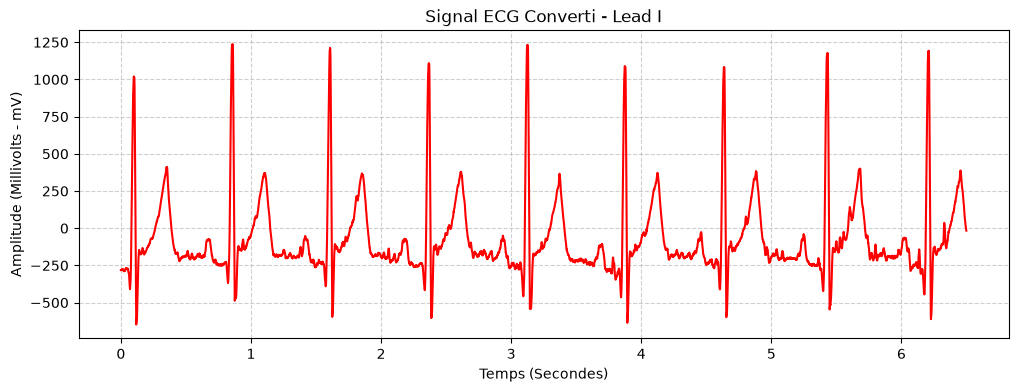

In [37]:
def plot_rescaled_ecg(time_array, ecg_array):
    """Affiche la piste 1 de l'ECG avec les vraies unités physiques (secondes et mV)."""
    plt.figure(figsize=(12, 4))
    # On trace la piste 0 (Lead I) en rouge pour bien la différencier de la brute
    plt.plot(time_array, ecg_array[:, 0], color='red') 
    plt.title("Signal ECG Converti - Lead I")
    plt.xlabel("Temps (Secondes)")
    plt.ylabel("Amplitude (Millivolts - mV)")
    plt.grid(True, linestyle='--', alpha=0.6) # Ajout d'une petite grille pour la lisibilité
    plt.show()

# On exécute la fonction
plot_rescaled_ecg(time, rescaled_ecg_data)